In [4]:
# Filepath imports
# Making sure filepath runs smoothly
import sys
import os

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled
env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/bin/python
R libPaths now:
[1] "/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/R/library"

phyloseq installed? True


In [5]:
# imports for data analysis

# data analysis
import pandas as pd
import numpy as np
import json

# qiime and related
import qiime2
from qiime2 import Metadata, Artifact
import biom

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression

from scipy.interpolate import UnivariateSpline

In [6]:
# Loading in absolute quant data for train/test/validation split
# Should run log transformation
abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
abs_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv')
abs_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv')

rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')
rel_test = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv')
rel_val = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv')

/tmp/ipykernel_58507/2900004183.py:3: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv')
/tmp/ipykernel_58507/2900004183.py:7: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv')


In [20]:
# Creating X and Y features
# Using American Gut Microbiome Project age cutoffs, remove outliers
abs_train = abs_train.loc[(abs_train["age"] >= 20) & (abs_train["age"] <= 69)]
abs_test = abs_test.loc[(abs_test["age"] >= 20) & (abs_test["age"] <= 69)]
abs_val = abs_val.loc[(abs_val["age"] >= 20) & (abs_val["age"] <= 69)]

rel_train = rel_train.loc[(rel_train["age"] >= 20) & (rel_train["age"] <= 69)]
rel_test = rel_test.loc[(rel_test["age"] >= 20) & (rel_test["age"] <= 69)]
rel_val = rel_val.loc[(rel_val["age"] >= 20) & (rel_val["age"] <= 69)]

# Absolute quant data
abs_X_train = abs_train[abs_train.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_train = abs_train['age']

abs_X_test = abs_test[abs_test.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_test  = abs_test['age']

abs_X_val = abs_val[abs_val.columns[:1148]].drop(columns=['original_SampleID'])
abs_Y_val  = abs_val['age']

# Relative abundance data
rel_X_train = rel_train[rel_train.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_train = rel_train['age']

rel_X_test = rel_test[rel_test.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_test  = rel_test['age']

rel_X_val = rel_val[rel_val.columns[:1148]].drop(columns=['original_SampleID'])
rel_Y_val  = rel_val['age']

In [21]:
# Preprocessing
# Using log transform to standardize the data
# Absolute quant data
abs_X_train_log = abs_X_train.copy()
abs_X_train_log = np.log1p(abs_X_train_log)

abs_X_test_log = abs_X_test.copy()
abs_X_test_log = np.log1p(abs_X_test_log)

abs_X_val_log = abs_X_val.copy()
abs_X_val_log = np.log1p(abs_X_val_log)

# Relative abundance data
rel_X_train_log = rel_X_train.copy()
rel_X_train_log = np.log1p(rel_X_train_log)

rel_X_test_log = rel_X_test.copy()
rel_X_test_log = np.log1p(rel_X_test_log)

rel_X_val_log = rel_X_val.copy()
rel_X_val_log = np.log1p(rel_X_val_log)

In [9]:
# Need to edit this
abs_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
abs_rf_reg.fit(abs_X_train_log, abs_Y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [10]:
val_preds = abs_rf_reg.predict(abs_X_val_log)

mae = mean_absolute_error(abs_Y_val, val_preds)
rmse = mean_squared_error(abs_Y_val, val_preds, squared=False)
r2 = r2_score(abs_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 10.900273631840797
RMSE (years): 12.586266642720483
R²: 0.22891857256877313


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


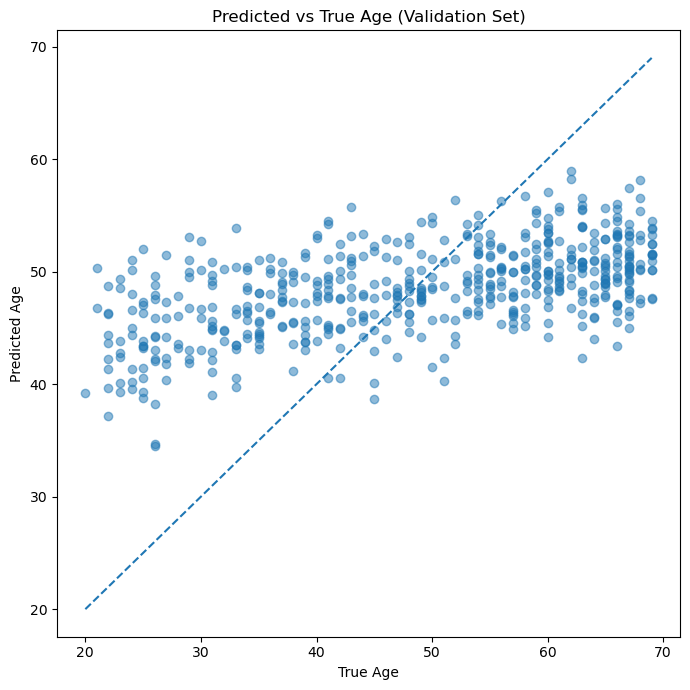

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(abs_Y_val, val_preds, alpha=0.5)

# Perfect prediction line
min_age = min(abs_Y_val.min(), val_preds.min())
max_age = max(abs_Y_val.max(), val_preds.max())
plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs True Age (Validation Set)")
plt.tight_layout()
plt.show()

In [22]:
# Trying the methodology from this paper: https://journals.asm.org/doi/10.1128/msystems.00630-19
# Sort by age (required for spline stability)
order = np.argsort(abs_Y_val)
x = np.array(abs_Y_val)[order]
y = np.array(val_preds)[order]

# Fit smoothing spline
spline = UnivariateSpline(
    x,
    y,
    s=len(x) * np.var(y)
)

In [23]:
# Expected microbiota age from spline
expected_microbiota_age = spline(abs_Y_val)

# Relative microbiota age
relative_microbiota_age = val_preds - expected_microbiota_age

In [24]:
abs_Y_val

0      51.0
1      43.0
2      42.0
3      39.0
4      24.0
       ... 
631    39.0
632    65.0
634    69.0
635    56.0
636    53.0
Name: age, Length: 536, dtype: float64

In [25]:
val_results = pd.DataFrame({
    "chronological_age": abs_Y_val,
    "microbiota_age": val_preds,
    "expected_microbiota_age": expected_microbiota_age,
})

val_results["relative_microbiota_age"] = (
    val_results["microbiota_age"] - 
    val_results["expected_microbiota_age"]
)

In [16]:
abs_Y_val.head()

0    51.0
1    43.0
2    42.0
3    39.0
4    24.0
Name: age, dtype: object

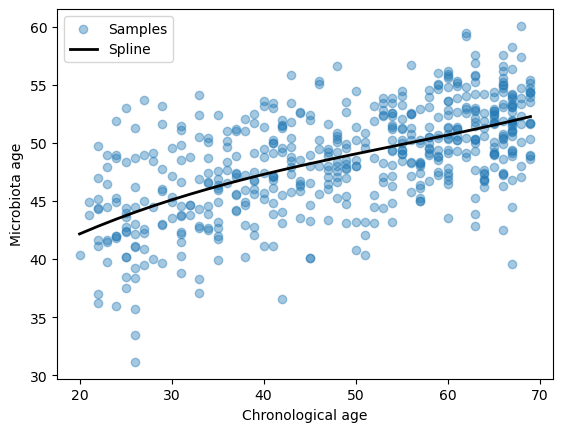

In [37]:
plt.scatter(abs_Y_val, val_preds, alpha=0.4, label="Samples")
plt.plot(x, spline(x), color="black", linewidth=2, label="Spline")
plt.xlabel("Chronological age")
plt.ylabel("Microbiota age")
plt.legend()
plt.show()

In [27]:
## Comparison to Relative Abundance

In [28]:
rel_rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rel_rf_reg.fit(rel_X_train, rel_Y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [29]:
val_preds = rel_rf_reg.predict(rel_X_val)

mae = mean_absolute_error(rel_Y_val, val_preds)
rmse = mean_squared_error(rel_Y_val, val_preds, squared=False)
r2 = r2_score(rel_Y_val, val_preds)

print("MAE (years):", mae)
print("RMSE (years):", rmse)
print("R²:", r2)

MAE (years): 10.489402985074626
RMSE (years): 12.182945886809506
R²: 0.27754464117216016


/home/cisicat/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


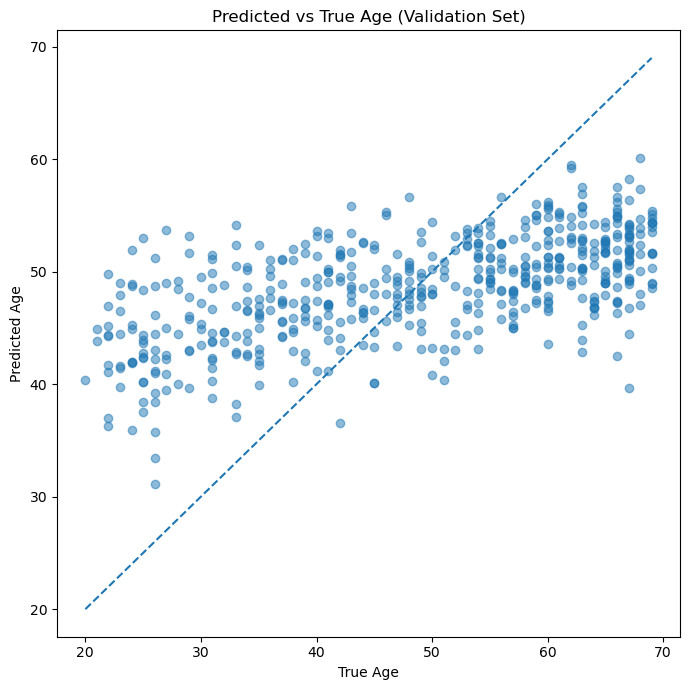

In [31]:
plt.figure(figsize=(7, 7))
plt.scatter(rel_Y_val, val_preds, alpha=0.5)

# Perfect prediction line
min_age = min(rel_Y_val.min(), val_preds.min())
max_age = max(rel_Y_val.max(), val_preds.max())
plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs True Age (Validation Set)")
plt.tight_layout()
plt.show()

In [32]:
# Sort by age (required for spline stability)
order = np.argsort(rel_Y_val)
x = np.array(rel_Y_val)[order]
y = np.array(val_preds)[order]

# Fit smoothing spline
spline = UnivariateSpline(
    x,
    y,
    s=len(x) * np.var(y)
)

In [33]:
# Expected microbiota age from spline
expected_microbiota_age = spline(rel_Y_val)

# Relative microbiota age
relative_microbiota_age = val_preds - expected_microbiota_age

In [34]:
val_results = pd.DataFrame({
    "chronological_age": abs_Y_val,
    "microbiota_age": val_preds,
    "expected_microbiota_age": expected_microbiota_age,
})

val_results["relative_microbiota_age"] = (
    val_results["microbiota_age"] - 
    val_results["expected_microbiota_age"]
)

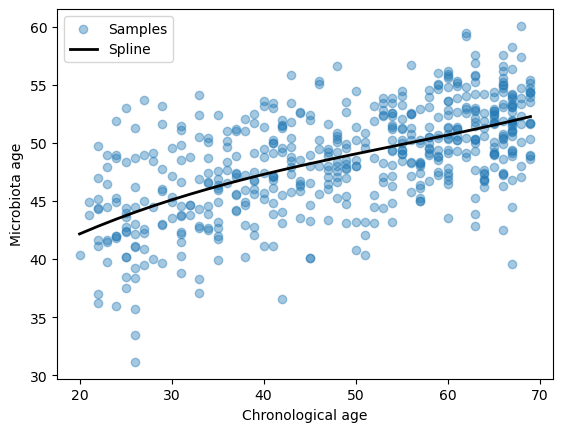

In [35]:
plt.scatter(rel_Y_val, val_preds, alpha=0.4, label="Samples")
plt.plot(x, spline(x), color="black", linewidth=2, label="Spline")
plt.xlabel("Chronological age")
plt.ylabel("Microbiota age")
plt.legend()
plt.show()